# **Part II: applying the lab techniques to the project\\**

# OPSSAT-AD: Satellite Telemetry Anomaly Detection

For this project we initially considered three different public datasets related to security and anomalies:

- a network intrusion dataset (CIC-IDS 2017),
- the TON_IoT collection (IoT / IIoT telemetry and network data),
- the OPSSAT-AD dataset, built from a CubeSat mission operated by the European Space Agency.

The first two datasets are mainly focused on general network traffic and IoT devices (fridge, thermostat, GPS tracker, etc.). They are very useful for intrusion detection, but they only capture the “ground” side of the problem. Since our project specifically targets cyberattacks and anomalies on satellites and space infrastructure, we decided to focus on **OPSSAT-AD**, which is directly based on real satellite telemetry.

OPSSAT-AD provides preprocessed segments of telemetry signals. Each sample corresponds to a segment of a telemetry channel and comes with:
- a set of handcrafted features (mean, variance, standard deviation, kurtosis, skewness, number of peaks, differences of variance, etc.),
- metadata such as segment length, duration and sampling rate,
- a binary label `anomaly` (0 = nominal, 1 = anomalous),
- a `train` flag indicating whether the segment belongs to the training or test split defined by the authors.

In other words, the dataset is already in a tabular format designed for machine learning experiments. In a real industrial setting, a data engineer would start from raw telemetry streams and build this kind of feature table. Here we adopt the point of view of a data scientist working in a research context: we assume that the feature extraction pipeline has already been done, and we concentrate on model selection, hyperparameter tuning and ensemble methods.

In this notebook we will:

- load and briefly explore the OPSSAT-AD tabular dataset (`dataset.csv`),
- use the predefined `train` split to separate training and test data,
- build baseline classifiers (Decision Tree and SVM),
- tune their hyperparameters with `GridSearchCV`,
- apply ensemble techniques (Bagging and a hybrid VotingClassifier),
- evaluate and compare the models using accuracy, precision, recall, F1-score and confusion matrices,
- discuss which approach offers the best trade-off between detection performance and operational usefulness for satellite telemetry monitoring.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing & Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, VotingClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# Data size
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (2123, 23)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12


## Dataset description

The OPSSAT-AD tabular dataset (`dataset.csv`) contains precomputed features extracted from telemetry segments of the ESA OPSSAT CubeSat. Each row corresponds to one segment of a telemetry channel, and the columns describe statistical and structural properties of the signal over that segment.

In our copy of the dataset we have:

- **2123 segments** in total
- **23 columns**, including:
  - identifiers and metadata: `segment`, `channel`, `sampling`, `duration`, `len`
  - statistical features: `mean`, `var`, `std`, `kurtosis`, `skew`
  - shape / peak features: `n_peaks`, `smooth10_n_peaks`, `smooth20_n_peaks`, `diff_peaks`, `diff2_peaks`
  - variance- and gap-related features: `diff_var`, `diff2_var`, `gaps_squared`, `len_weighted`, `var_div_duration`, `var_div_len`
  - supervision and split information: `anomaly`, `train`

The target variable is:

- **`anomaly`**  
  - `0` = nominal segment  
  - `1` = anomalous segment  

The proportion of anomalies is around one fifth of the dataset, which makes this a slightly imbalanced but still workable binary classification problem.

The column **`train`** is a binary flag provided by the dataset authors:

- `train = 1` → sample belongs to the training set  
- `train = 0` → sample belongs to the test set  

In our case this leads to:

- **1594 training samples**
- **529 test samples**

We use this predefined split instead of drawing a new one with `train_test_split`, so that our experiments remain comparable to the original OPSSAT-AD benchmark and we do not “leak” information from the test set into training. The only preprocessing we apply is:

- standardising numerical features,
- one-hot encoding the categorical feature `channel`.

No heavy cleaning or feature engineering is performed here, because the goal of this lab is to study model selection, hyperparameter tuning and ensemble methods on a satellite telemetry problem, not to redesign the whole signal-processing pipeline behind OPSSAT-AD.

In [3]:
# Setup Target & Features
# We exclude the ID, the Target, AND the split flag to avoid leakage
drop_cols = ["anomaly", "segment", "train"]

X = df.drop(columns=drop_cols)
y = df["anomaly"]

# Apply predefined split
mask_train = (df["train"] == 1)
mask_test  = (df["train"] == 0)

X_train = X[mask_train].copy()
X_test  = X[mask_test].copy()

y_train = y[mask_train].copy()
y_test  = y[mask_test].copy()

print(f"Train set: {X_train.shape} | Test set: {X_test.shape}")

Train set: (1594, 20) | Test set: (529, 20)


In [4]:
# Auto-detect numerical columns instead of manual list comprehension
# (Robust way to handle features)
cat_cols = ["channel"]
num_cols = X.select_dtypes(include=['number']).columns

# Define Transformation Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), num_cols),
    ('ohe',    OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [5]:
SEED = 42

# Define Pipelines directly
# Using 'clf' (classifier) as step name is a standard convention
pipe_dt = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=SEED))
])

pipe_svm = Pipeline([
    ("prep", preprocessor),
    ("clf", SVC(probability=True, random_state=SEED))
])

# Search spaces
grid_dt = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [3, 5, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

grid_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["linear", "rbf"],
    "clf__gamma": ["scale", "auto"],
}

In [6]:
# Tuning Decision Tree
print("Tuning Decision Tree...")
gs_dt = GridSearchCV(pipe_dt, grid_dt, cv=3, scoring="f1", n_jobs=-1, verbose=1)
gs_dt.fit(X_train, y_train)

# Tuning SVM
print("\nTuning SVM...")
gs_svm = GridSearchCV(pipe_svm, grid_svm, cv=3, scoring="f1", n_jobs=-1, verbose=1)
gs_svm.fit(X_train, y_train)

# Quick Recap
print("-" * 50)
print(f"DT  Best F1: {gs_dt.best_score_:.4f} | Params: {gs_dt.best_params_}")
print(f"SVM Best F1: {gs_svm.best_score_:.4f} | Params: {gs_svm.best_params_}")

Tuning Decision Tree...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Tuning SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
--------------------------------------------------
DT  Best F1: 0.7681 | Params: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
SVM Best F1: 0.7085 | Params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}


In [7]:
import time

# Storage for comparison
results = {}

def benchmark_model(name, model, X, y):
    """Eval model and store metrics"""

    # Inference Time
    t0 = time.time()
    preds = model.predict(X)
    dt = time.time() - t0

    # Metrics
    acc = accuracy_score(y, preds)
    f1  = f1_score(y, preds, zero_division=0)

    # Store
    results[name] = {
        "Accuracy": acc,
        "F1-Score": f1,
        "Latency (s)": dt,
        "Predictions": preds
    }

    # Display
    print(f"=== {name} ===")
    print(f"Latency: {dt:.4f}s ({dt/len(X)*1000:.2f} ms/sample)")
    print(f"Accuracy: {acc:.2%}")
    print(f"F1-Score: {f1:.4f}")
    print("-" * 30)

# Evaluate Best Models from GridSearch
benchmark_model("DecisionTree (Tuned)", gs_dt.best_estimator_, X_test, y_test)
benchmark_model("SVM (Tuned)", gs_svm.best_estimator_, X_test, y_test)

=== DecisionTree (Tuned) ===
Latency: 0.0080s (0.02 ms/sample)
Accuracy: 94.33%
F1-Score: 0.8485
------------------------------
=== SVM (Tuned) ===
Latency: 0.0127s (0.02 ms/sample)
Accuracy: 94.52%
F1-Score: 0.8557
------------------------------


In [8]:
# --- Ensemble Learning Strategy ---

# Helper to create bagging pipelines
def make_bagging_pipe(base_estimator, name="bagging"):
    return Pipeline([
        ("prep", preprocessor),
        ("bag", BaggingClassifier(
            estimator=base_estimator,
            n_estimators=10,
            max_samples=0.8,
            n_jobs=-1,
            random_state=SEED
        ))
    ])

# 1. Extract best base models (without their original prep step)
best_dt = gs_dt.best_estimator_.named_steps["clf"]
best_svm = gs_svm.best_estimator_.named_steps["clf"]

# 2. Create Ensembles
pipe_bag_dt = make_bagging_pipe(best_dt, "Bagged Tree")
pipe_bag_svm = make_bagging_pipe(best_svm, "Bagged SVM")

# 3. Train & Eval Bagging
print("Training Bagging models...")
pipe_bag_dt.fit(X_train, y_train)
benchmark_model("Bagging Decision Tree", pipe_bag_dt, X_test, y_test)

pipe_bag_svm.fit(X_train, y_train)
benchmark_model("Bagging SVM", pipe_bag_svm, X_test, y_test)

# 4. Hybrid Voting (Soft)
print("\nTraining Voting Ensemble...")
voting_clf = VotingClassifier(
    estimators=[
        ('bag_dt', pipe_bag_dt),
        ('bag_svm', pipe_bag_svm)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)
benchmark_model("Voting (Hybrid)", voting_clf, X_test, y_test)

Training Bagging models...
=== Bagging Decision Tree ===
Latency: 0.0308s (0.06 ms/sample)
Accuracy: 94.33%
F1-Score: 0.8485
------------------------------
=== Bagging SVM ===
Latency: 0.0848s (0.16 ms/sample)
Accuracy: 94.33%
F1-Score: 0.8529
------------------------------

Training Voting Ensemble...
=== Voting (Hybrid) ===
Latency: 0.1311s (0.25 ms/sample)
Accuracy: 94.90%
F1-Score: 0.8670
------------------------------



Leaderboard:
                       F1-Score  Accuracy Latency (s)
Voting (Hybrid)        0.866995   0.94896    0.131083
SVM (Tuned)            0.855721   0.94518    0.012655
Bagging SVM            0.852941  0.943289     0.08476
DecisionTree (Tuned)   0.848485  0.943289     0.00805
Bagging Decision Tree  0.848485  0.943289    0.030846


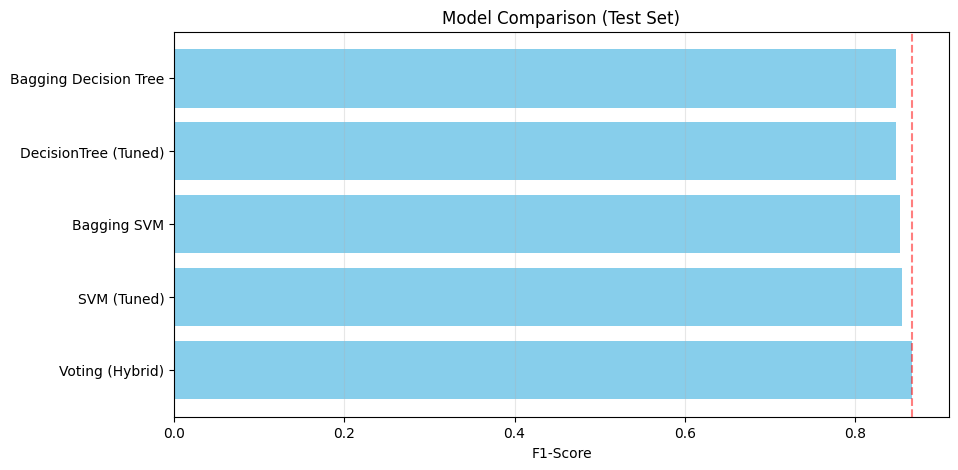

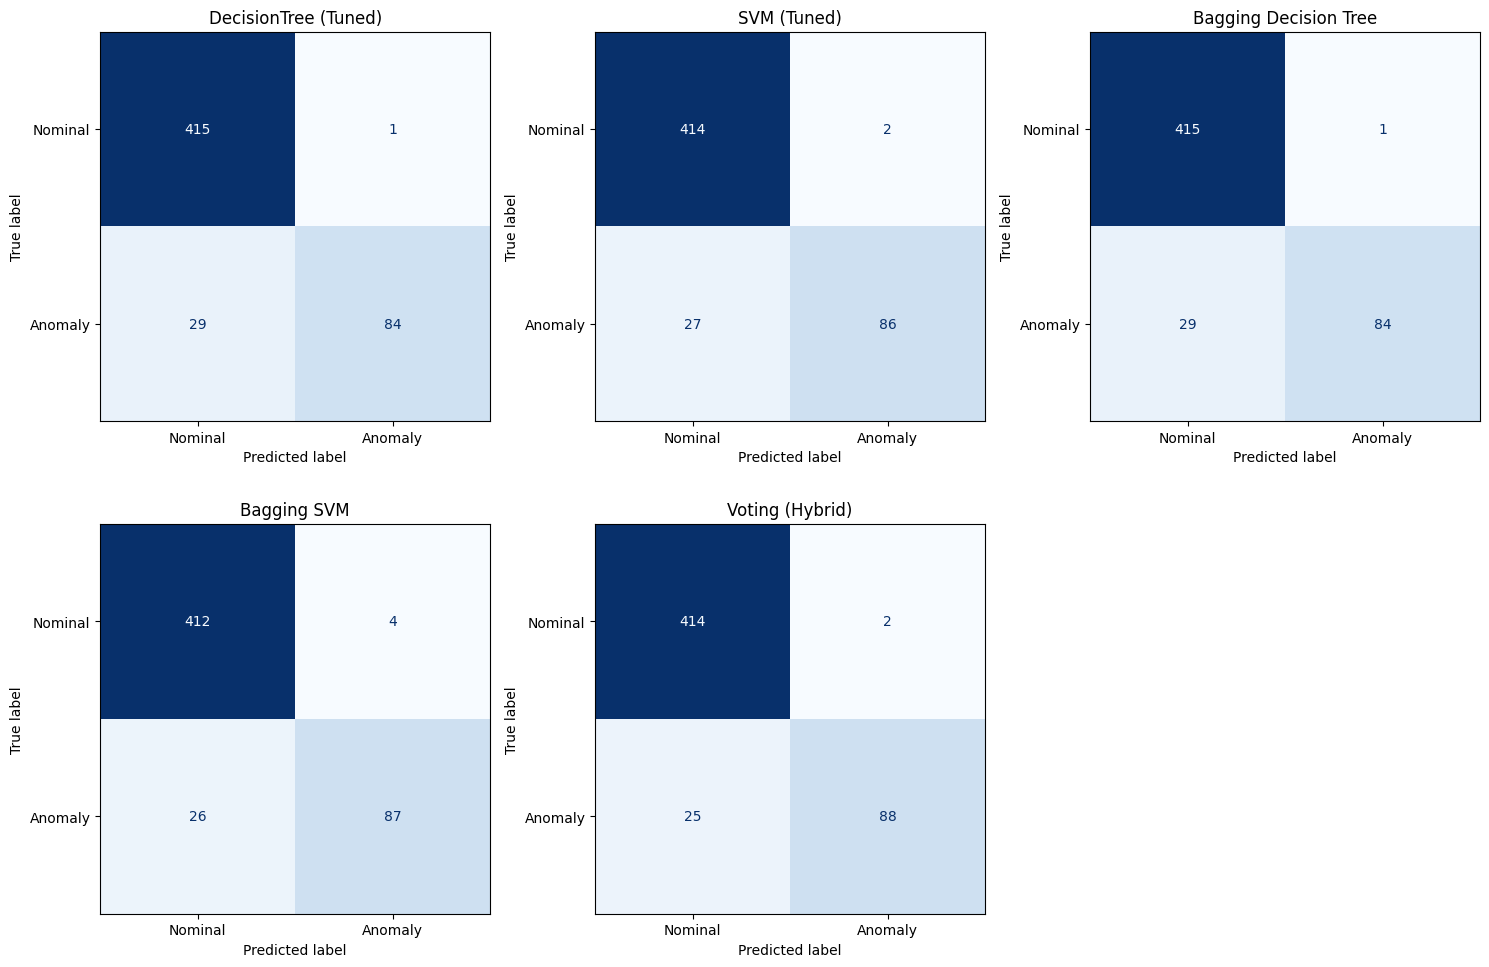

In [9]:
# 1. Visualize Metrics
# Convert results to DataFrame for easier plotting
df_res = pd.DataFrame(results).T.sort_values("F1-Score", ascending=False)

print("\nLeaderboard:")
print(df_res[["F1-Score", "Accuracy", "Latency (s)"]])

# Plot F1-Score Comparison
plt.figure(figsize=(10, 5))
bars = plt.barh(df_res.index, df_res["F1-Score"], color='skyblue')
plt.xlabel("F1-Score")
plt.title("Model Comparison (Test Set)")
plt.axvline(x=df_res["F1-Score"].max(), color='red', linestyle='--', alpha=0.5) # Mark best score
plt.grid(axis='x', alpha=0.3)
plt.show()

# 2. Confusion Matrices (Grid view)
# Create a grid to show all matrices at once
n_models = len(results)
cols = 3
rows = (n_models // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["Predictions"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Nominal", "Anomaly"])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name)

# Hide empty subplots
for i in range(idx + 1, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Evaluation on the OPSSAT-AD dataset

All models achieve strong performance on the satellite telemetry anomaly detection task, but there are some clear differences.

The tuned Decision Tree reaches an accuracy of about 94% with a very high precision (almost no false positives), but its recall is more limited: it misses around 29 anomalous segments on the test set. This means that the tree is conservative and tends to classify borderline cases as normal.

The tuned SVM slightly improves the F1-score compared to the tree. It still keeps the number of false positives low, but recovers a few more anomalies (higher recall). This is consistent with the idea that SVMs can model more complex decision boundaries in the feature space.

Bagging has very little effect on the Decision Tree in this dataset: the confusion matrix and the F1-score are almost unchanged, suggesting that the single tuned tree is already relatively stable. For the SVM, bagging gives a small boost in recall (fewer missed anomalies) at the cost of a few more false positives.

The hybrid VotingClassifier, which combines the bagged SVM and the bagged Decision Tree with soft voting, provides the best overall trade-off. It achieves the highest F1-score, with the lowest number of missed anomalies (false negatives) while keeping the number of false alarms (false positives) very small.

From a satellite operations point of view, this trade-off is important: missing anomalies can be risky for the health of the spacecraft, whereas a small number of additional false alarms is usually acceptable. In that sense, the voting ensemble is the most attractive option for monitoring OPSSAT telemetry, while the tuned SVM alone remains a strong and simpler baseline.

## Conclusion – Part II: applying the lab techniques to the project

In the first part of the lab we experimented with relatively simple datasets (Breast Cancer, SVM vs Decision Tree, Bagging and Voting) in order to understand how hyperparameter tuning and ensemble methods affect performance. In this second part, we applied exactly the same ideas to a more realistic scenario: anomaly detection in satellite telemetry from the OPSSAT mission.

Among several candidate datasets (network intrusion data, IoT/IIoT traffic and satellite telemetry), we deliberately chose OPSSAT-AD because it is directly related to space systems and already provides a clean, tabular representation of telemetry segments. This allowed us to work in a data scientist mindset: rather than spending most of the time on raw log parsing and feature extraction, we assumed that the engineering pipeline was already in place and focused on model selection, GridSearchCV and ensembles.

Using the predefined train/test split and the anomaly labels, we built and tuned Decision Tree and SVM baselines, then extended them with Bagging and a hybrid VotingClassifier. The experiments show that:
- SVM models provide slightly better F1-scores than a single Decision Tree;
- Bagging is mainly helpful for the SVM, by improving recall at the cost of a few extra false alarms;
- the Voting ensemble achieves the best global trade-off between accuracy, recall and robustness.

Overall, this part of the project demonstrates how the techniques introduced in the lab (hyperparameter search, bagging, voting) can be transferred from toy datasets to a realistic satellite telemetry problem. The same workflow could later be reused on other sources such as TON_IoT or network intrusion datasets, or extended with more advanced ensembles and anomaly detection methods.


Model Export for Deployment
To integrate this Voting Classifier into the global "Mission Control" system, we need to serialize the trained model and the associated scaler. This allows the master script to load the exact same configuration used during training without retraining.

In [10]:
import os
import joblib

print("--- EXPORT: SATELLITE MODEL ---")

output_file = 'model_satellite.pkl'

# Dumping the Voting Classifier pipeline
joblib.dump(voting_clf, output_file)

# Sanity check: verify file existence and size
if os.path.exists(output_file):
    f_size = os.path.getsize(output_file) / 1024  # Size in KB
    print(f"Model successfully exported: {output_file} ({f_size:.2f} KB)")
else:
    print("Error: Export failed.")

--- EXPORT: SATELLITE MODEL ---
Model successfully exported: model_satellite.pkl (1013.86 KB)
